In [42]:
print("how to make non linear")

how to make non linear model


In [10]:
!kaggle datasets download -d jangedoo/utkface-new

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:02<00:00, 169MB/s]



### Somethings about dataset


the image name contains information about the gender age for e.g

first part contain age likee if it is written 100_something then his age is 100 and if it is written 10_ then his age is 10

Similarly second part contain gender if it is 0 then he is male . if she it is 1 then she is female

In [11]:
!unzip utkface-new.zip

Streaming output truncated to the last 5000 lines.
  inflating: utkface_aligned_cropped/crop_part1/34_1_0_20170109004755204.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_0_20170111182452832.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170103230340961.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170104011329697.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170104165020320.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_1_20170108230211421.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104022134829.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104023010725.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104172537171.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104201443273.jpg.chip.jpg  
  inflating: utkface_aligned_cropped/crop_part1/34_1_2_20170104204327

In [12]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

In [13]:
folder_path = '/content/UTKFace'

In [14]:
age = []
gender = []
img_path = []

for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'img': img_path
})

In [15]:
len(age)

23708

In [16]:
#train test split

In [17]:
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

train_df = df.iloc[:20000]
test_df = df.iloc[20000:]

In [18]:
df.shape

(23708, 3)

In [19]:
#dataset Creation

IMG_SIZE = (200, 200)
BATCH_SIZE = 32

def load_image(filename, age, gender):

    path = tf.strings.join([folder_path, "/", filename])

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32)
    }

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["img"].values,
        train_df["age"].values,
        train_df["gender"].values
    )
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

In [21]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["img"].values,
        test_df["age"].values,
        test_df["gender"].values
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [22]:
#build ResNET50 model

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(200, 200, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
x = base_model.output

x = Flatten()(x)

age_branch = Dense(512, activation="relu")(x)
age_branch = Dense(512, activation="relu")(age_branch)

gender_branch = Dense(512, activation="relu")(x)
gender_branch = Dense(512, activation="relu")(gender_branch)

age_output = Dense(
    1,
    activation="linear",
    name="age"
)(age_branch)

gender_output = Dense(
    1,
    activation="sigmoid",
    name="gender"
)(gender_branch)

In [24]:
model = Model(
    inputs=base_model.input,
    outputs=[age_output, gender_output]
)

In [26]:
#compile

model.compile(
    optimizer="adam",
    loss={
        "age": "mae",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": "mae",
        "gender": "accuracy"
    },
    loss_weights={
        "age": 1,
        "gender": 99
    }
)

In [27]:
#train

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 121ms/step - age_loss: 15.0371 - age_mae: 15.0371 - gender_accuracy: 0.5270 - gender_loss: 0.8283 - loss: 97.0397 - val_age_loss: 14.5022 - val_age_mae: 14.5011 - val_gender_accuracy: 0.5343 - val_gender_loss: 0.6912 - val_loss: 82.9285
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 112ms/step - age_loss: 13.8381 - age_mae: 13.8381 - gender_accuracy: 0.5205 - gender_loss: 0.6925 - loss: 82.3917 - val_age_loss: 13.0711 - val_age_mae: 13.0690 - val_gender_accuracy: 0.5343 - val_gender_loss: 0.6912 - val_loss: 81.4946
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - age_loss: 12.9163 - age_mae: 12.9163 - gender_accuracy: 0.5205 - gender_loss: 0.6924 - loss: 81.4670 - val_age_loss: 11.7066 - val_age_mae: 11.7047 - val_gender_accuracy: 0.5343 - val_gender_loss: 0.6911 - val_loss: 80.1189
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - age_loss: 12.1699 - age_mae: 12.1699 - gender_accuracy: 0.5205 - gender_loss: 0.6925 - loss: 80.7229

In [28]:
#The code builds a multi-task deep learning model that predicts both age and gender from a face image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
--- Prediction for image: face.jpg.chip.jpg ---
Predicted Age: 30.91
Predicted Gender: Male (Probability: 0.48)


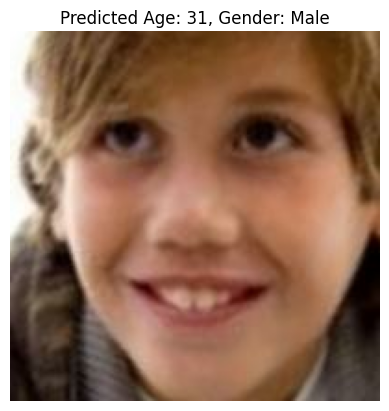

In [30]:
import matplotlib.pyplot as plt
import numpy as np


sample_img_filename = 'face.jpg.chip.jpg'


original_folder_path = folder_path
folder_path = '/content'

# Load and preprocess the image
# The load_image function returns image and a dictionary of labels, we only need the image for prediction
# Age and gender labels are placeholders here as we don't have them for a new image
processed_image, _ = load_image(sample_img_filename, 0, 0)

# Restore original folder_path if needed later
folder_path = original_folder_path

# Add a batch dimension to the image for prediction
image_for_prediction = tf.expand_dims(processed_image, axis=0)

# Make predictions
predictions = model.predict(image_for_prediction)

predicted_age = predictions[0][0][0]
predicted_gender_proba = predictions[1][0][0]
predicted_gender = 1 if predicted_gender_proba > 0.5 else 0 # 0 for male, 1 for female

print(f"--- Prediction for image: {sample_img_filename} ---")
print(f"Predicted Age: {predicted_age:.2f}")
print(f"Predicted Gender: {'Female' if predicted_gender == 1 else 'Male'} (Probability: {predicted_gender_proba:.2f})")

# Display the image
plt.imshow(processed_image.numpy())
plt.title(f"Predicted Age: {predicted_age:.0f}, Gender: {'Female' if predicted_gender == 1 else 'Male'}")
plt.axis('off')
plt.show()